<a href="https://colab.research.google.com/github/Kusum067/FinSight-AI-Powered-Stock-Correlation-Analyzer/blob/main/stock_correlation_api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf

stock1 = yf.download("RELIANCE.NS", start="2018-01-01")
stock2 = yf.download("TCS.NS", start="2018-01-01")

stock1.head()

/tmp/ipykernel_16627/2394920358.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock1 = yf.download("RELIANCE.NS", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_16627/2394920358.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock2 = yf.download("TCS.NS", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2018-01-01,401.864868,407.585270,400.870972,407.585270,9453202
2018-01-02,402.483185,406.193737,400.384963,403.300393,9499419
2018-01-03,404.095551,409.042944,403.322514,408.601196,13507800
2018-01-04,406.525085,407.187693,404.493122,405.575361,9008932
2018-01-05,407.828156,409.440487,406.502971,407.187664,7441284


In [ ]:
returns1 = stock1['Close'].squeeze().pct_change()
returns2 = stock2['Close'].squeeze().pct_change()

In [ ]:
corr = returns1.rolling(100).corr(returns2)
corr = corr.dropna()

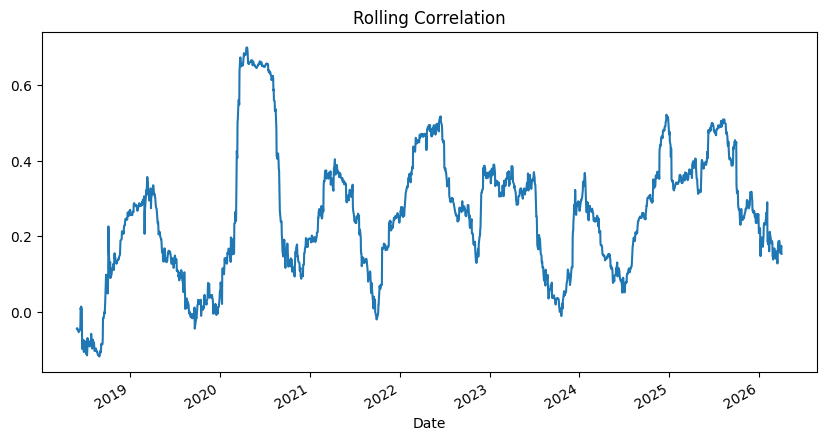

In [ ]:
import matplotlib.pyplot as plt

corr.plot(figsize=(10,5))
plt.title("Rolling Correlation")
plt.show()

In [ ]:
data = corr.values

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(data, order=(2,1,2))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1938
Model:                 ARIMA(2, 1, 2)   Log Likelihood                5159.815
Date:                Thu, 02 Apr 2026   AIC                         -10309.630
Time:                        09:18:34   BIC                         -10281.786
Sample:                             0   HQIC                        -10299.390
                               - 1938                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0041      0.912     -0.005      0.996      -1.791       1.783
ar.L2         -0.0144      0.604     -0.024      0.981      -1.197       1.168
ma.L1         -0.0040      0.913     -0.004      0.9

In [ ]:
forecast = model_fit.forecast(steps=10)

print(forecast)

[0.15299976 0.15362039 0.15362225 0.15361331 0.15361332 0.15361345
 0.15361345 0.15361344 0.15361344 0.15361344]


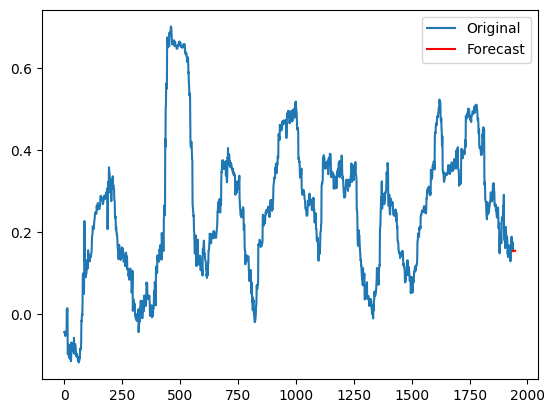

In [ ]:
import matplotlib.pyplot as plt

plt.plot(data, label="Original")
plt.plot(range(len(data), len(data)+10), forecast, label="Forecast", color='red')
plt.legend()
plt.show()

In [ ]:
residuals = model_fit.resid

In [ ]:
import numpy as np

X = []
y = []

data = residuals

for i in range(20, len(data)):
    X.append(data[i-20:i])
    y.append(data[i])

X, y = np.array(X), np.array(y)

In [ ]:
X = X.reshape((X.shape[0], X.shape[1], 1))

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(20,1)))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse')

model_lstm.fit(X, y, epochs=5)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.8096e-04
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.8222e-04
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.8136e-04
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.8085e-04
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.8001e-04


In [ ]:
lstm_pred = model_lstm.predict(X[-1].reshape(1,20,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step


In [ ]:
final_prediction = forecast[0] + lstm_pred[0][0]

print("Final Hybrid Prediction:", final_prediction)

Final Hybrid Prediction: 0.15320566787829257


In [ ]:
if final_prediction > 0.7:
    print("High correlation → avoid combining assets")
elif final_prediction > 0.3:
    print("Moderate correlation → okay with caution")
else:
    print("Low correlation → good for diversification")

Low correlation → good for diversification


In [ ]:
def predict_correlation(ticker1, ticker2):
    stock1 = yf.download(ticker1, start="2018-01-01")
    stock2 = yf.download(ticker2, start="2018-01-01")

    returns1 = stock1['Close'].squeeze().pct_change()
    returns2 = stock2['Close'].squeeze().pct_change()

    corr = returns1.rolling(100).corr(returns2).dropna()

    data = corr.values

    from statsmodels.tsa.arima.model import ARIMA
    model = ARIMA(data, order=(2,1,2))
    model_fit = model.fit()

    forecast = model_fit.forecast(steps=1)

    residuals = model_fit.resid

    X, y = [], []
    for i in range(20, len(residuals)):
        X.append(residuals[i-20:i])
        y.append(residuals[i])

    X, y = np.array(X), np.array(y)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    model_lstm = Sequential()
    model_lstm.add(LSTM(50, activation='relu', input_shape=(20,1)))
    model_lstm.add(Dense(1))
    model_lstm.compile(optimizer='adam', loss='mse')
    model_lstm.fit(X, y, epochs=3, verbose=0)

    lstm_pred = model_lstm.predict(X[-1].reshape(1,20,1), verbose=0)

    final = forecast[0] + lstm_pred[0][0]

    return final

In [ ]:
result = predict_correlation("INFY.NS", "HDFCBANK.NS")
print(result)

/tmp/ipykernel_16627/930720969.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock1 = yf.download(ticker1, start="2018-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_16627/930720969.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock2 = yf.download(ticker2, start="2018-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


0.23165075065115634


In [ ]:
!pip install yfinance fastapi uvicorn nest-asyncio pyngrok

In [ ]:
from fastapi import FastAPI

app = FastAPI()

@app.get("/predict")
def predict(stock1: str, stock2: str):
    result = predict_correlation(stock1, stock2)

    if result > 0.7:
        msg = "High correlation → avoid combining assets ⚠️"
    elif result > 0.3:
        msg = "Moderate correlation → okay with caution ⚠️"
    else:
        msg = "Low correlation → good for diversification ✅"

    return {
        "correlation": float(result),
        "suggestion": msg
    }

In [ ]:
import nest_asyncio
from pyngrok import ngrok
import uvicorn
import os
from dotenv import load_dotenv

nest_asyncio.apply()

# load .env
load_dotenv()

# get token safely
ngrok.set_auth_token(os.getenv("NGROK_TOKEN"))

# create public URL
public_url = ngrok.connect(8000)
print(" OPEN THIS:", public_url)

# run server
config = uvicorn.Config(app, host="0.0.0.0", port=8000)
server = uvicorn.Server(config)

await server.serve()

TypeError: expected str, bytes or os.PathLike object, not NoneType